## CATS AND DOGS CLASSIFICATION WITH SVM

In [1]:
!pip install kaggle -q

In [2]:
from google.colab import files

files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"vanshh07","key":"a72e04ccf5d01648a1509d07369386b3"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets list -s dogs

ref                                                 title                                       size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------  ------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shaunthesheep/microsoft-catsvsdogs-dataset          Cats-vs-Dogs                           825979578  2020-03-12 05:34:30.730000         106753        964  0.875            
d4rklucif3r/cat-and-dogs                            Cat & Dogs                             228496389  2021-06-07 11:39:13.983000          10081        134  1                
jessicali9530/stanford-dogs-dataset                 Stanford Dogs Dataset                  786955428  2019-11-13 06:20:35.130000          75317       1157  0.75             
marquis03/cats-and-dogs                             Cats and Dogs                           10219362  2023-10-27 10:48:19.220000  

In [7]:
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:12<00:00, 67.8MB/s]



In [8]:
!unzip -q microsoft-catsvsdogs-dataset.zip

In [9]:
import os

for root, dirs, files in os.walk('/content'):
    if len(dirs) > 0:
        print(root)

/content
/content/.config
/content/.config/logs
/content/PetImages


In [10]:
import os

print(os.listdir('/content/PetImages'))

['Dog', 'Cat']


In [11]:

import cv2
import numpy as np

In [12]:
cat_path = "/content/PetImages/Cat"
dog_path = "/content/PetImages/Dog"

print("Cats:", len(os.listdir(cat_path)))
print("Dogs:", len(os.listdir(dog_path)))

Cats: 12501
Dogs: 12501


In [13]:
data = []
labels = []

image_size = 64

# Cat Images

In [35]:
for file in os.listdir(cat_path)[:2000]:

    try:
        img = cv2.imread(
            os.path.join(cat_path, file),
            cv2.IMREAD_GRAYSCALE
        )

        img = cv2.resize(img, (64, 64))

        data.append(img.flatten())
        labels.append(0)

    except:
        pass

# Dog Images

In [37]:
for file in os.listdir(dog_path)[:2000]:

    try:
        img = cv2.imread(
            os.path.join(dog_path, file),
            cv2.IMREAD_GRAYSCALE
        )

        img = cv2.resize(img, (64, 64))

        data.append(img.flatten())
        labels.append(1)

    except:
        pass

In [38]:
print("Images Loaded:", len(data))

Images Loaded: 7997


In [39]:
X = np.array(data)
y = np.array(labels)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (7997, 4096)
y Shape: (7997,)


In [40]:
X = np.array(data, dtype=np.float32)
X = X / 255.0

y = np.array(labels)

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 6397
Testing Samples: 1600


In [42]:
from sklearn.svm import SVC


model = SVC(
    kernel='rbf',
    gamma='scale'
)

model.fit(X_train, y_train)

SVC()

In [43]:
predictions = model.predict(X_test)

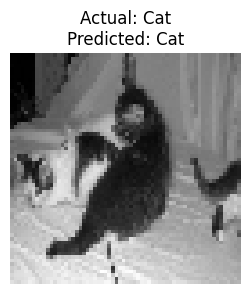

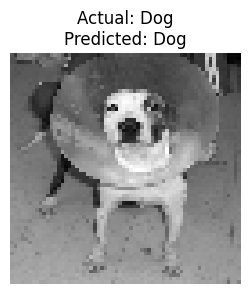

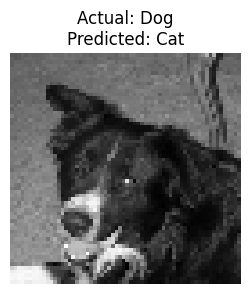

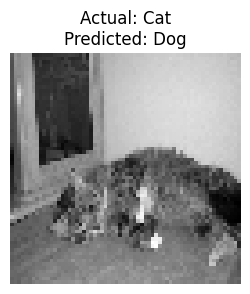

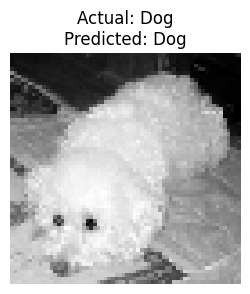

In [44]:
import matplotlib.pyplot as plt
import random

indices = random.sample(range(len(X_test)), 5)

for idx in indices:

    plt.figure(figsize=(3,3))

    plt.imshow(
        X_test[idx].reshape(64,64),
        cmap='gray'
    )

    actual = "Dog" if y_test[idx] == 1 else "Cat"
    predicted = "Dog" if predictions[idx] == 1 else "Cat"

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis('off')
    plt.show()

In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 82.25 %


In [46]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import classification_report

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)

print("Accuracy :", round(accuracy*100,2), "%")
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy : 82.25 %
Precision: 0.7977
Recall   : 0.9612

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.59      0.71       595
           1       0.80      0.96      0.87      1005

    accuracy                           0.82      1600
   macro avg       0.85      0.77      0.79      1600
weighted avg       0.84      0.82      0.81      1600



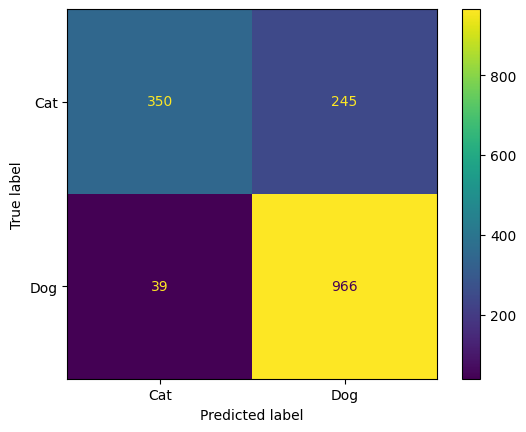

In [47]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()
plt.show()